<a href="https://colab.research.google.com/github/rishika01-code/Credit-card-Fraud-Detection/blob/main/Credit_Card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,f1_score,confusion_matrix



In [58]:
dataset = pd.read_csv('/content/creditcard.csv')
# print(dataset.head(10))
dataset.drop(columns=['Time'],axis=1,inplace= True)
print(dataset.info)

<bound method DataFrame.info of                V1         V2        V3        V4        V5        V6  \
0       -1.359807  -0.072781  2.536347  1.378155 -0.338321  0.462388   
1        1.191857   0.266151  0.166480  0.448154  0.060018 -0.082361   
2       -1.358354  -1.340163  1.773209  0.379780 -0.503198  1.800499   
3       -0.966272  -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4       -1.158233   0.877737  1.548718  0.403034 -0.407193  0.095921   
...           ...        ...       ...       ...       ...       ...   
284802 -11.881118  10.071785 -9.834783 -2.066656 -5.364473 -2.606837   
284803  -0.732789  -0.055080  2.035030 -0.738589  0.868229  1.058415   
284804   1.919565  -0.301254 -3.249640 -0.557828  2.630515  3.031260   
284805  -0.240440   0.530483  0.702510  0.689799 -0.377961  0.623708   
284806  -0.533413  -0.189733  0.703337 -0.506271 -0.012546 -0.649617   

              V7        V8        V9       V10  ...       V21       V22  \
0       0.239599  0.098698  

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
#check dataset is balanced or imbalaced
print(dataset['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


Fraud =1 Legit =0

In [61]:
print(dataset.describe())

                 V1            V2            V3            V4            V5  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15  9.604066e-16   
std    1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00  1.380247e+00   
min   -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00 -1.137433e+02   
25%   -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01 -6.915971e-01   
50%    1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02 -5.433583e-02   
75%    1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01  6.119264e-01   
max    2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01  3.480167e+01   

                 V6            V7            V8            V9           V10  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15  2.239053e-15   
std    1.332271e+00  1.237094e+00  1.194353e+00  1.

In [62]:
legit = dataset[dataset.Class == 0]
Fraud = dataset[dataset.Class == 1]
print(Fraud.head(10))

            V1        V2        V3        V4        V5        V6        V7  \
541  -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545 -2.537387   
623  -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823  0.325574   
4920 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788  0.562320   
6108 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536 -3.496197   
6329  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746  1.713445   
6331  0.008430  4.137837 -6.240697  6.675732  0.768307 -3.353060 -1.631735   
6334  0.026779  4.132464 -6.560600  6.348557  1.329666 -2.513479 -1.689102   
6336  0.329594  3.712889 -5.775935  6.078266  1.667359 -2.420168 -0.812891   
6338  0.316459  3.809076 -5.615159  6.047445  1.554026 -2.651353 -0.746579   
6427  0.725646  2.300894 -5.329976  4.007683 -1.730411 -1.732193 -3.968593   

            V8        V9       V10  ...       V21       V22       V23  \
541   1.391657 -2.770089 -2.772272  ...  0.517232 -0.035049 -0.46521

In [63]:
new_df = legit.sample(n=492)
print(new_df.head(10))

              V1        V2        V3        V4        V5        V6        V7  \
144411 -0.522359  1.587248  1.333929  2.819754 -0.319308 -0.070999  0.060348   
174887  1.726420 -0.893403 -0.075549  0.597347 -1.223633 -0.520929 -0.693977   
231502  1.843770  0.569669 -1.409137  3.761415  0.803743 -0.484641  0.783642   
186488  1.688791 -1.928346 -2.731894 -3.012003  0.298836  0.632809 -0.089494   
46867   1.400078 -1.472098  1.067411 -1.542806 -1.944702  0.244178 -1.837542   
101609 -0.427120  0.586290  1.582986 -1.259149 -0.395395 -0.921350  0.348319   
217036 -1.476159  1.444610 -0.579759 -2.789591  0.468555 -0.553518  0.424070   
21377   1.141477  0.108509 -0.132901  0.318391  0.185805 -0.254926  0.294878   
217185 -0.925901 -0.644901 -0.933951 -4.629003  1.299917 -1.593392  0.524607   
46479  -3.342513 -2.770958  0.923316  1.949572  0.228935 -0.689461 -0.419406   

              V8        V9       V10  ...       V21       V22       V23  \
144411  0.544814 -1.805840  0.885666  ...  0

In [64]:
new_dataset =pd.concat([new_df,Fraud],axis =0)
# print(new_dataset.head(10))
print(new_dataset.shape)

(984, 30)


In [65]:
x = new_dataset.drop(columns=['Class'],axis = 1)
y = new_dataset['Class']

In [66]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)
print(y_train.head(10))

175289    0
195136    0
245347    1
243393    1
273727    0
154633    1
268557    0
223572    1
229730    1
125701    0
Name: Class, dtype: int64


In [67]:
#using logistic regresstion
model = LogisticRegression(max_iter=2000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=2000)

In [68]:
y_pred = model.predict(x_train)
print(y_pred)
# print(type(y_pred)) it gives in from of numpy array

[0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 1
 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 0 0 0 1 1 1 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1
 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 1 0 1 1 0 0
 1 1 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1
 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 1 1 1 0 0
 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 1 1 1 1 0 0 1 1 0 0
 0 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 1 0 0 1 1
 0 0 1 0 0 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0
 0 0 0 0 1 1 0 0 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1
 1 0 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 0 0 1 0 0 0 1 1 1
 1 0 0 1 0 1 0 0 0 1 1 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 0
 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 0 1 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0
 1 0 1 0 0 0 1 0 1 0 0 1 

In [69]:
accuracy = accuracy_score(y_pred , y_train)
print(f"model accuracy = {accuracy*100:2f}%")

model accuracy = 95.806861%


In [70]:
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       397
           1       0.98      0.94      0.96       390

    accuracy                           0.96       787
   macro avg       0.96      0.96      0.96       787
weighted avg       0.96      0.96      0.96       787



In [71]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

Training Random Forest...


In [72]:
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=1)
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_test)

Training Gradient Boosting...


In [73]:
y_pred_lr = model.predict(x_test)

print("\nCalculating accuracy...")




Calculating accuracy...


In [74]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"Logistic Regression: {acc_lr*100:.2f}%")
print(f"Random Forest: {acc_rf*100:.2f}%")
print(f"Gradient Boosting: {acc_gb*100:.2f}%")


Logistic Regression: 92.89%
Random Forest: 92.39%
Gradient Boosting: 92.89%


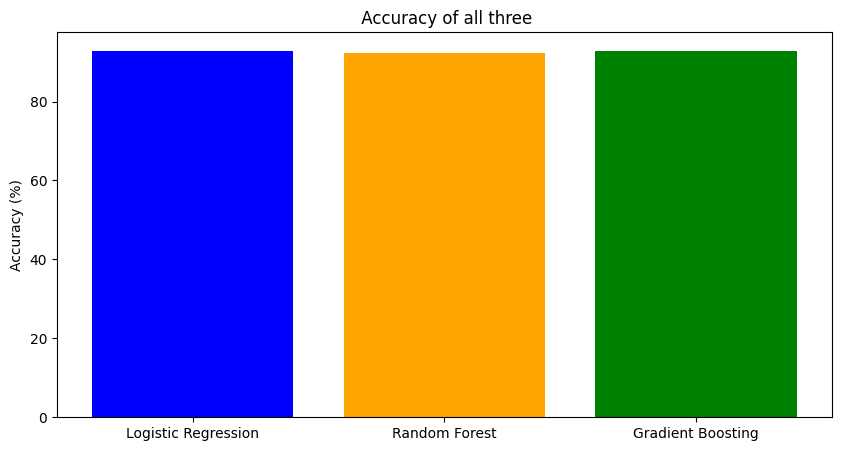

In [75]:
models_list = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
accuracies = [acc_lr*100, acc_rf*100, acc_gb*100]

plt.figure(figsize=(10, 5))
plt.bar(models_list, accuracies, color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy (%)')
plt.title(' Accuracy of all three')
plt.show()

In [76]:
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[92  3]
 [12 90]]


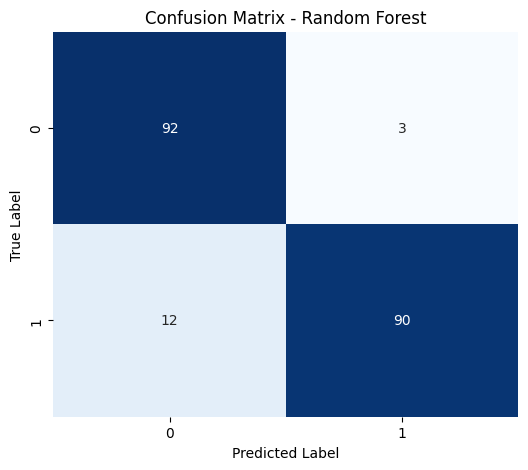


True Negatives (TN): 92
False Positives (FP): 3
False Negatives (FN): 12
True Positives (TP): 90


In [77]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"\nTrue Negatives (TN): {cm[0][0]}")
print(f"False Positives (FP): {cm[0][1]}")
print(f"False Negatives (FN): {cm[1][0]}")
print(f"True Positives (TP): {cm[1][1]}")

In [84]:
# Predict a single transaction

index = 10    # Change this to any index between 0 and len(x_test)-1

transaction = x_test.iloc[[index]]

actual = y_test.iloc[index]

prediction = model.predict(transaction)[0]

print("Transaction Index :", index)
print("Actual Result     :", "Fraud" if actual == 1 else "Legitimate")
print("Predicted Result  :", "Fraud" if prediction == 1 else "Legitimate")

Transaction Index : 10
Actual Result     : Legitimate
Predicted Result  : Legitimate


In [85]:
# Prediction probability
probability = model.predict_proba(transaction)[0]

print(f"Probability of Legitimate : {probability[0]*100:.2f}%")
print(f"Probability of Fraud      : {probability[1]*100:.2f}%")

Probability of Legitimate : 73.20%
Probability of Fraud      : 26.80%
